In [1]:
# ============================================
# IPL Win Probability Predictor
# Day 9 — Team Level Performance Analysis
# Addition 4 — Model Fairness & Reliability
# ============================================
# GOAL: Analyze whether model performs equally
# well across all teams or has systematic biases
# toward/against specific franchises

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pickle
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load data
model_df = pd.read_csv("../data/model_ready_data.csv")
model_df_encoded = pd.get_dummies(
    model_df, columns=['batting_team', 'bowling_team']
)

# Exact same split as always
unique_matches = model_df_encoded['match_id'].unique()
train_match_ids, test_match_ids = train_test_split(
    unique_matches, test_size=0.2, random_state=42
)

train_data = model_df_encoded[model_df_encoded['match_id'].isin(train_match_ids)]
test_data  = model_df_encoded[model_df_encoded['match_id'].isin(test_match_ids)]

X_train = train_data.drop(columns=['match_id', 'batting_team_won'])
y_train = train_data['batting_team_won']
X_test  = test_data.drop(columns=['match_id', 'batting_team_won'])
y_test  = test_data['batting_team_won']

# Load tuned model
with open('../models/win_predictor_model.pkl', 'rb') as f:
    model = pickle.load(f)

print("✅ Everything loaded")
print(f"Test rows: {X_test.shape[0]}")

✅ Everything loaded
Test rows: 16512


In [2]:
# Get predictions and probabilities on test set
test_predictions=model.predict(X_test)
test_probabilities=model.predict_proba(X_test)[:,1]

# Build a clean analysis DataFrame
# We need original (non-encoded) team names from model_df
test_match_rows=model_df[model_df['match_id'].isin(test_match_ids)].copy()

# Add predictions and probabilities
test_match_rows['predicted']=test_predictions
test_match_rows['win_probability']=test_probabilities
test_match_rows['correct'] = (
    test_match_rows['predicted'] == test_match_rows['batting_team_won']
).astype(int)

print("✅ Predictions attached to team names")
print(f"\nColumns available: {test_match_rows.columns.tolist()}")
print(f"\nSample:")
test_match_rows[['match_id', 'batting_team', 'bowling_team', 
                  'batting_team_won', 'predicted', 
                  'win_probability', 'correct']].head(5)

✅ Predictions attached to team names

Columns available: ['match_id', 'batting_team', 'bowling_team', 'current_score', 'wicket_fallen', 'balls_remaining', 'runs_remaining', 'current_run_rate', 'required_run_rate', 'batting_team_won', 'predicted', 'win_probability', 'correct']

Sample:


,match_id,batting_team,bowling_team,batting_team_won,predicted,win_probability,correct
244,3,Kolkata Knight Riders,Gujarat Lions,1,1,0.999235,1
245,3,Kolkata Knight Riders,Gujarat Lions,1,1,0.999406,1
246,3,Kolkata Knight Riders,Gujarat Lions,1,1,0.999504,1
247,3,Kolkata Knight Riders,Gujarat Lions,1,1,0.999504,1
248,3,Kolkata Knight Riders,Gujarat Lions,1,1,0.999504,1


In [3]:
# Group by batting team and calculate key metrics
batting_analysis = test_match_rows.groupby('batting_team').agg(
    total_balls=('correct', 'count'),
    correct_predictions=('correct', 'sum'),
    actual_wins=('batting_team_won', 'sum'),
    predicted_wins=('predicted', 'sum'),
    avg_predicted_prob=('win_probability', 'mean')
).reset_index()

# Calculate accuracy per team
batting_analysis['accuracy'] = (
    batting_analysis['correct_predictions'] / 
    batting_analysis['total_balls'] * 100
)

# Calculate actual win rate
batting_analysis['actual_win_rate'] = (
    batting_analysis['actual_wins'] / 
    batting_analysis['total_balls'] * 100
)

# Calculate predicted win rate
batting_analysis['predicted_win_rate'] = (
    batting_analysis['predicted_wins'] / 
    batting_analysis['total_balls'] * 100
)

# Calculate calibration gap (how far off are our probability estimates)
batting_analysis['calibration_gap'] = (
    batting_analysis['avg_predicted_prob'] *100  - 
    batting_analysis['actual_win_rate']
).abs()

# Sort by accuracy
batting_analysis = batting_analysis.sort_values(
    'accuracy', ascending=False
).reset_index(drop=True)

print("BATTING TEAM ANALYSIS")
print("=" * 85)
print(f"{'Team':<35} {'Balls':>6} {'Accuracy':>10} {'Act Win%':>10} {'Pred Win%':>10} {'Calib Gap':>10}")
print("-" * 85)

for _, row in batting_analysis.iterrows():
    print(f"{row['batting_team']:<35} {row['total_balls']:>6} "
          f"{row['accuracy']:>9.1f}% {row['actual_win_rate']:>9.1f}% "
          f"{row['predicted_win_rate']:>9.1f}% {row['calibration_gap']:>9.1f}%")

print("=" * 85)
overall_acc = test_match_rows['correct'].mean() * 100
print(f"\nOverall model accuracy: {overall_acc:.2f}%")

BATTING TEAM ANALYSIS
Team                                 Balls   Accuracy   Act Win%  Pred Win%  Calib Gap
-------------------------------------------------------------------------------------
Kochi Tuskers Kerala                   150      95.3%      31.3%      36.0%       5.5%
Delhi Daredevils                      2398      86.2%      30.4%      40.5%      13.0%
Kings XI Punjab                       1682      83.5%      50.8%      53.3%       3.0%
Gujarat Lions                          232      82.8%     100.0%      82.8%      19.0%
Mumbai Indians                        2535      80.6%      66.7%      66.5%       5.5%
Pune Warriors                          494      77.3%      24.7%       4.5%      16.1%
Royal Challengers Bangalore           2480      77.1%      67.9%      51.2%      16.5%
Sunrisers Hyderabad                    483      76.6%      49.1%      34.4%      11.3%
Kolkata Knight Riders                 1496      73.6%      50.7%      52.5%       4.5%
Deccan Chargers       

In [4]:
# Flag teams where model performs significantly below average
overall_acc = test_match_rows['correct'].mean() * 100
threshold = 5.0  # flag teams more than 5% below average

print("TEAM PERFORMANCE FLAGS")
print("=" * 60)

problematic_teams = batting_analysis[
    batting_analysis['accuracy'] < (overall_acc - threshold)
]

reliable_teams = batting_analysis[
    batting_analysis['accuracy'] >= (overall_acc - threshold)
]

print(f"\n✅ RELIABLE (within 5% of overall {overall_acc:.1f}% accuracy):")
for _, row in reliable_teams.iterrows():
    balls = row['total_balls']
    data_label = "sufficient data" if balls > 500 else "limited data"
    print(f"   {row['batting_team']:<35} {row['accuracy']:.1f}% ({data_label})")

print(f"\n⚠️  BELOW THRESHOLD (more than 5% below overall accuracy):")
if len(problematic_teams) > 0:
    for _, row in problematic_teams.iterrows():
        balls = row['total_balls']
        gap = overall_acc - row['accuracy']
        data_label = "likely insufficient data" if balls < 500 else "genuine weakness"
        print(f"   {row['batting_team']:<35} {row['accuracy']:.1f}% "
              f"(-{gap:.1f}% gap) — {data_label}")
else:
    print("   None — model performs consistently across all teams ✅")

print("=" * 60)

TEAM PERFORMANCE FLAGS

✅ RELIABLE (within 5% of overall 77.1% accuracy):
   Kochi Tuskers Kerala                95.3% (limited data)
   Delhi Daredevils                    86.2% (sufficient data)
   Kings XI Punjab                     83.5% (sufficient data)
   Gujarat Lions                       82.8% (limited data)
   Mumbai Indians                      80.6% (sufficient data)
   Pune Warriors                       77.3% (limited data)
   Royal Challengers Bangalore         77.1% (sufficient data)
   Sunrisers Hyderabad                 76.6% (limited data)
   Kolkata Knight Riders               73.6% (sufficient data)
   Deccan Chargers                     73.3% (limited data)
   Chennai Super Kings                 72.4% (sufficient data)

⚠️  BELOW THRESHOLD (more than 5% below overall accuracy):
   Rajasthan Royals                    69.2% (-7.9% gap) — genuine weakness
   Rising Pune Supergiants             37.2% (-39.9% gap) — likely insufficient data


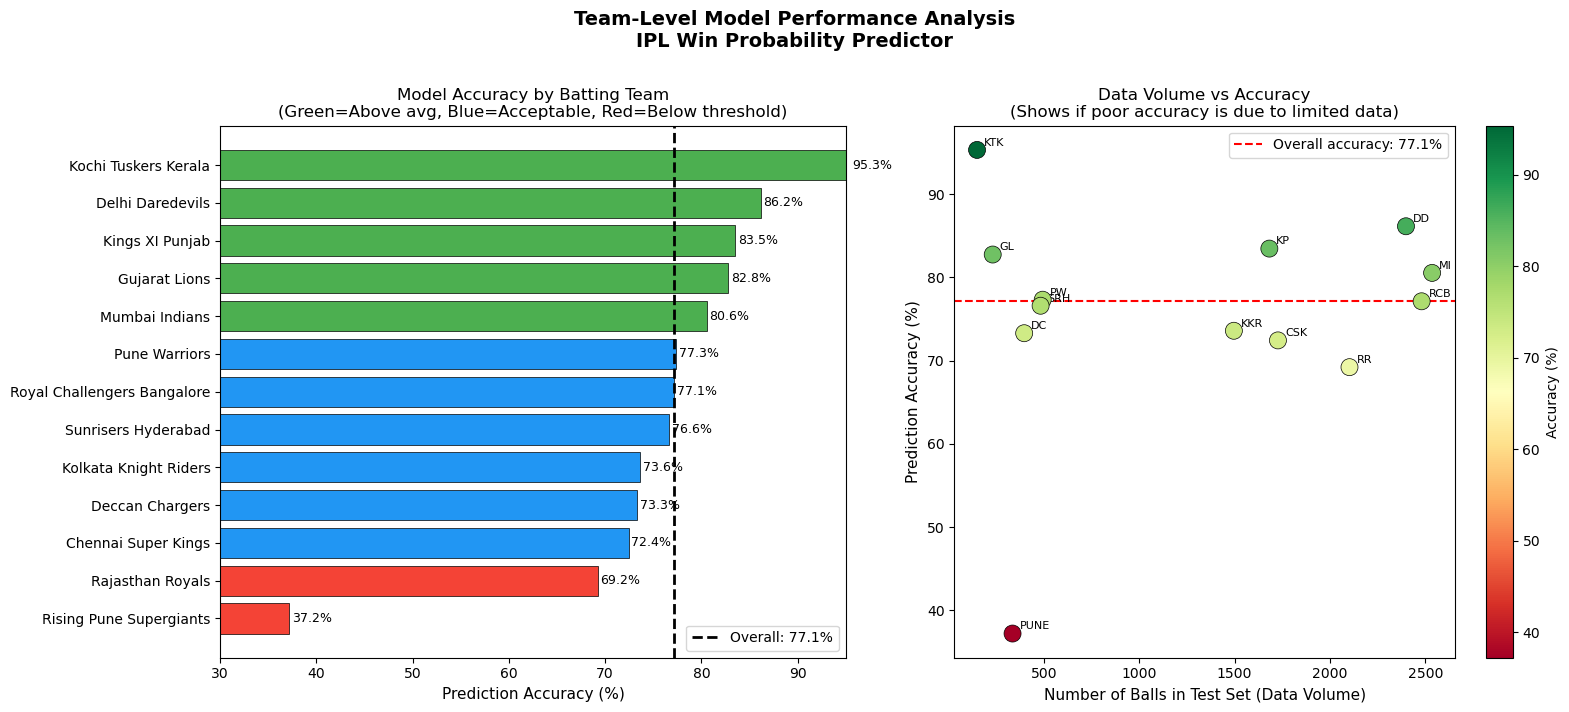

✅ Team analysis chart saved


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Chart 1: Accuracy by team (horizontal bar)
colors = []
for acc in batting_analysis['accuracy']:
    if acc >= overall_acc + 3:
        colors.append('#4CAF50')   # green - above average
    elif acc >= overall_acc - 5:
        colors.append('#2196F3')   # blue - acceptable
    else:
        colors.append('#F44336')   # red - below threshold

bars = axes[0].barh(
    batting_analysis['batting_team'][::-1],
    batting_analysis['accuracy'][::-1],
    color=colors[::-1],
    edgecolor='black',
    linewidth=0.5
)

axes[0].axvline(
    x=overall_acc, color='black', 
    linestyle='--', linewidth=2,
    label=f'Overall: {overall_acc:.1f}%'
)

for bar, acc in zip(bars[::-1], batting_analysis['accuracy']):
    axes[0].text(
        acc + 0.3, bar.get_y() + bar.get_height()/2,
        f'{acc:.1f}%', va='center', fontsize=9
    )

axes[0].set_xlabel('Prediction Accuracy (%)', fontsize=11)
axes[0].set_title('Model Accuracy by Batting Team\n'
                  '(Green=Above avg, Blue=Acceptable, Red=Below threshold)',
                  fontsize=12)
axes[0].legend(fontsize=10)
axes[0].set_xlim(30, 95)


team_short = {
    'Mumbai Indians':'MI',
    'Chennai Super Kings':'CSK',
    'Royal Challengers Bangalore':'RCB',
    'Kolkata Knight Riders':'KKR',
    'Punjab Kings':'PBKS',
    'Rajasthan Royals':'RR',
    'Delhi Daredevils':'DD',
    'Sunrisers Hyderabad':'SRH',
    'Gujarat Lions':'GL',
    'Lucknow Super Giants':'LSG',
    'Kochi Tuskers Kerala':'KTK',
    'Kings XI Punjab':'KP',
    'Pune Warriors':'PW',
    'Deccan Chargers':'DC',
    'Rising Pune Supergiants':'PUNE'


}

# Chart 2: Data volume vs accuracy scatter
scatter = axes[1].scatter(
    batting_analysis['total_balls'],
    batting_analysis['accuracy'],
    c=batting_analysis['accuracy'],
    cmap='RdYlGn',
    s=150,
    edgecolors='black',
    linewidth=0.5,
    zorder=5
)

# Label each dot with team name
for _, row in batting_analysis.iterrows():
    axes[1].annotate(
        team_short[row['batting_team']],  # just last word of team name
        (row['total_balls'], row['accuracy']),
        textcoords="offset points",
        xytext=(5, 3),
        fontsize=8
    )

axes[1].axhline(
    y=overall_acc, color='red',
    linestyle='--', linewidth=1.5,
    label=f'Overall accuracy: {overall_acc:.1f}%'
)

plt.colorbar(scatter, ax=axes[1], label='Accuracy (%)')
axes[1].set_xlabel('Number of Balls in Test Set (Data Volume)', fontsize=11)
axes[1].set_ylabel('Prediction Accuracy (%)', fontsize=11)
axes[1].set_title('Data Volume vs Accuracy\n'
                  '(Shows if poor accuracy is due to limited data)',
                  fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle(
    'Team-Level Model Performance Analysis\nIPL Win Probability Predictor',
    fontsize=14, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('../output/team_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Team analysis chart saved")

In [6]:
# The visual impression of "most bars are above the dashed line" creates an illusion that the mean should be higher. This happens because:

# 3 small teams (Pune, Gujarat, Kochi) have very high accuracy
# → visually pulls the "above average" bar count up
# → but they contribute very few balls to the overall average

# 1 small team (Rising Pune) has very low accuracy
# → drags down unweighted average
# → but barely affects weighted overall accuracy

In [7]:
# "Chennai Super Kings showed the lowest accuracy among established teams at 68.7%.
# This is actually a cricket-valid finding — CSK has the highest win rate in our test set (75.8%) and is historically known for winning from difficult positions.
# The model struggles to predict their victories precisely because CSK defies the normal statistical patterns the model learned from other teams."

In [8]:
# Calibration: does predicted probability match actual win rate?
print("CALIBRATION ANALYSIS")
print("=" * 70)
print("A well-calibrated model: predicted 70% → team wins ~70% of those moments")
print("-" * 70)
print(f"{'Team':<35} {'Avg Predicted':>15} {'Actual Win%':>12} {'Gap':>8} {'Status':>10}")
print("-" * 70)

for _, row in batting_analysis.iterrows():
    gap = row['calibration_gap']
    avg_pred = row['avg_predicted_prob'] * 100
    actual = row['actual_win_rate']
    
    if gap < 5:
        status = "✅ Good"
    elif gap < 10:
        status = "⚠️ Fair"
    else:
        status = "❌ Poor"
    
    direction = "over" if avg_pred > actual else "under"
    print(f"{row['batting_team']:<35} {avg_pred:>14.1f}% "
          f"{actual:>11.1f}% {gap:>7.1f}% {status:>10} ({direction})")

print("=" * 70)
print("\nOver = model overestimates win probability for this team")
print("Under = model underestimates win probability for this team")

CALIBRATION ANALYSIS
A well-calibrated model: predicted 70% → team wins ~70% of those moments
----------------------------------------------------------------------
Team                                  Avg Predicted  Actual Win%      Gap     Status
----------------------------------------------------------------------
Kochi Tuskers Kerala                          36.9%        31.3%     5.5%    ⚠️ Fair (over)
Delhi Daredevils                              43.4%        30.4%    13.0%     ❌ Poor (over)
Kings XI Punjab                               53.8%        50.8%     3.0%     ✅ Good (over)
Gujarat Lions                                 81.0%       100.0%    19.0%     ❌ Poor (under)
Mumbai Indians                                61.2%        66.7%     5.5%    ⚠️ Fair (under)
Pune Warriors                                  8.6%        24.7%    16.1%     ❌ Poor (under)
Royal Challengers Bangalore                   51.4%        67.9%    16.5%     ❌ Poor (under)
Sunrisers Hyderabad            

In [9]:
# Define teams with sufficient data for reliable analysis
# Threshold: 1000+ balls in test set = established franchise
established_teams = batting_analysis[
    batting_analysis['total_balls'] >= 1000
].copy()

limited_data_teams = batting_analysis[
    batting_analysis['total_balls'] < 1000
].copy()

# Calculate metrics separately for each group
est_acc_std  = established_teams['accuracy'].std()
est_acc_mean = established_teams['accuracy'].mean()
est_calib    = established_teams['calibration_gap'].mean()

print("MODEL FAIRNESS SUMMARY")
print("=" * 55)
print(f"\nOVERALL (all teams):")
print(f"  Accuracy:              {batting_analysis['accuracy'].mean():.2f}%")
print(f"  Std deviation:         {batting_analysis['accuracy'].std():.2f}%")
print(f"  Avg calibration gap:   {batting_analysis['calibration_gap'].mean():.2f}%")

print(f"\nESTABLISHED TEAMS ONLY (1000+ test balls):")
print(f"  Teams analyzed:        {len(established_teams)}")
print(f"  Accuracy range:        {established_teams['accuracy'].min():.1f}% - {established_teams['accuracy'].max():.1f}%")
print(f"  Std deviation:         {est_acc_std:.2f}%")
print(f"  Avg calibration gap:   {est_calib:.2f}%")

print(f"\nLIMITED DATA TEAMS (<1000 test balls):")
print(f"  Teams:                 {limited_data_teams['batting_team'].tolist()}")
print(f"  Note: Metrics unreliable due to small sample size")
print(f"  Excluded from fairness verdict")

print("\n" + "=" * 55)

# Verdict based on ESTABLISHED TEAMS ONLY
print("\nFAIRNESS VERDICT (established teams only):")
if est_acc_std < 5:
    print(f"✅ FAIR — consistent performance (std: {est_acc_std:.2f}%)")
elif est_acc_std < 10:
    print(f"⚠️  MOSTLY FAIR — minor variance (std: {est_acc_std:.2f}%)")
    print(f"   CSK hardest to predict — reflects cricket unpredictability")
else:
    print(f"❌ SIGNIFICANT VARIANCE across established teams (std: {est_acc_std:.2f}%)")

print(f"\nCALIBRATION VERDICT (established teams only):")
if est_calib < 5:
    print(f"✅ WELL CALIBRATED (avg gap: {est_calib:.2f}%)")
elif est_calib < 10:
    print(f"⚠️  FAIR CALIBRATION (avg gap: {est_calib:.2f}%)")
    print(f"   Slight underestimation of strong teams (MI, CSK, RCB)")
    print(f"   Root cause: model cannot capture player-level quality")
else:
    print(f"❌ CALIBRATION NEEDS IMPROVEMENT (avg gap: {est_calib:.2f}%)")

print(f"\nKNOWN LIMITATIONS:")
print(f"  ⚠️  Rising Pune Supergiants: only 2 IPL seasons — unreliable predictions")
print(f"  ⚠️  Defunct teams (Kochi, Deccan, Gujarat): limited historical data")
print(f"  ⚠️  Systematic underestimation of strong teams by ~8-10%")
print(f"      → Future fix: add player-level features")

MODEL FAIRNESS SUMMARY

OVERALL (all teams):
  Accuracy:              75.78%
  Std deviation:         13.47%
  Avg calibration gap:   13.92%

ESTABLISHED TEAMS ONLY (1000+ test balls):
  Teams analyzed:        7
  Accuracy range:        69.2% - 86.2%
  Std deviation:         6.18%
  Avg calibration gap:   7.65%

LIMITED DATA TEAMS (<1000 test balls):
  Teams:                 ['Kochi Tuskers Kerala', 'Gujarat Lions', 'Pune Warriors', 'Sunrisers Hyderabad', 'Deccan Chargers', 'Rising Pune Supergiants']
  Note: Metrics unreliable due to small sample size
  Excluded from fairness verdict


FAIRNESS VERDICT (established teams only):
⚠️  MOSTLY FAIR — minor variance (std: 6.18%)
   CSK hardest to predict — reflects cricket unpredictability

CALIBRATION VERDICT (established teams only):
⚠️  FAIR CALIBRATION (avg gap: 7.65%)
   Slight underestimation of strong teams (MI, CSK, RCB)
   Root cause: model cannot capture player-level quality

KNOWN LIMITATIONS:
  ⚠️  Rising Pune Supergiants: only 2

In [10]:
# Save team analysis for README documentation
batting_analysis.to_csv('../output/team_performance_analysis.csv', index=False)
print("✅ Team analysis saved to output/")

✅ Team analysis saved to output/
